<a href="https://colab.research.google.com/github/pprieri/ml/blob/main/Fashion_MNIST_DDMLP_%2B_Conv2D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### This Notebook is part of Kaggle's Fashion MNIST Handwritten digits competition.

### I applied a simple Deep Dumb MLP and also a Conv2D NN.


**Context**

Fashion-MNIST is a dataset of Zalando's article images—consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes. Zalando intends Fashion-MNIST to serve as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms. It shares the same image size and structure of training and testing splits.

The original MNIST dataset contains a lot of handwritten digits. Members of the AI/ML/Data Science community love this dataset and use it as a benchmark to validate their algorithms. In fact, MNIST is often the first dataset researchers try. "If it doesn't work on MNIST, it won't work at all", they said. "Well, if it does work on MNIST, it may still fail on others."

Zalando seeks to replace the original MNIST dataset

**Content**

Each image is 28 pixels in height and 28 pixels in width, for a total of 784 pixels in total. Each pixel has a single pixel-value associated with it, indicating the lightness or darkness of that pixel, with higher numbers meaning darker. This pixel-value is an integer between 0 and 255. The training and test data sets have 785 columns. The first column consists of the class labels (see above), and represents the article of clothing. The rest of the columns contain the pixel-values of the associated image.

To locate a pixel on the image, suppose that we have decomposed x as x = i * 28 + j, where i and j are integers between 0 and 27. The pixel is located on row i and column j of a 28 x 28 matrix.
For example, pixel31 indicates the pixel that is in the fourth column from the left, and the second row from the top, as in the ascii-diagram below.


Labels

Each training and test example is assigned to one of the following labels:

0 T-shirt/top
1 Trouser
2 Pullover
3 Dress
4 Coat
5 Sandal
6 Shirt
7 Sneaker
8 Bag
9 Ankle boot


TL;DR

Each row is a separate image
Column 1 is the class label.
Remaining columns are pixel numbers (784 total).
Each value is the darkness of the pixel (1 to 255)

More info can be found here: https://www.kaggle.com/zalando-research/fashionmnist

### Download data

In [20]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  
# Then move kaggle.json into the folder where the API expects to find it.
!mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
User uploaded file "kaggle.json" with length 67 bytes


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Set-up

In [22]:
import tensorflow as tf
import tensorflow.keras as keras
import pandas as pd
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
from os import path, getcwd, chdir

In [23]:
%cd './drive/MyDrive/Colab Notebooks/Data/Fashion MNIST'

[Errno 2] No such file or directory: './drive/MyDrive/Colab Notebooks/Data/Fashion MNIST'
/content/drive/MyDrive/Colab Notebooks/Data/Fashion MNIST


In [24]:
!ls

fashion-mnist_test.csv	    fashion-mnist_train.csv
fashion-mnist_test.csv.zip  fashion-mnist_train.csv.zip


In [25]:
!unzip fashion-mnist_test.csv.zip
!unzip fashion-mnist_train.csv.zip

Archive:  fashion-mnist_test.csv.zip
replace fashion-mnist_test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fashion-mnist_test.csv  
Archive:  fashion-mnist_train.csv.zip
replace fashion-mnist_train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fashion-mnist_train.csv  


In [26]:
df_train_full = pd.read_csv('fashion-mnist_train.csv',header=0,sep=',')

print(df_train_full.shape)
df_train_full.head(3)

(60000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,0,0,105,92,101,107,100,132,0,0,2,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,150,...,211,220,214,74,0,255,222,128,0,0,0,0,0,0,0,0,0,44,12,0,0,40,134,162,191,214,163,146,165,79,0,0,0,30,43,0,0,0,0,0


In [27]:
df_test = pd.read_csv('fashion-mnist_test.csv',header=0,sep=',')
print(df_test.shape)
df_test.head(3)

(10000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,0,0,34,29,7,0,11,24,0,0,3,3,1,0,1,1,0,0,0,0,0,4,0,0,1,0,0,0,0,0,...,242,245,224,245,234,0,3,0,0,0,0,0,0,0,0,0,0,0,0,37,69,94,123,127,138,138,142,145,135,125,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,209,190,181,150,170,193,180,219,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,24,...,248,238,80,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,174,233,155,0,65,235,216,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,17,0,0,0,0,0,0,0,0,12,94,68,14,0,0,0,0,0,0,0,0,0,0,0,38,106,94,89,94,68,...,0,0,0,0,0,0,87,12,26,0,0,0,0,0,0,0,46,50,29,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,63,53,31,0,0,0


In [28]:
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))

    return df

df_train_full = reduce_mem_usage(df_train_full)
df_test = reduce_mem_usage(df_test)

Memory usage after optimization is: 89.55 MB
Decreased by 75.1%
Memory usage after optimization is: 14.90 MB
Decreased by 75.1%


In [29]:
print('\nX_test shape and dtypes \n ')
X_test = df_test

print(X_test.shape,'\n')
print(X_test.dtypes)


X_test shape and dtypes 
 
(10000, 785) 

label        int8
pixel1       int8
pixel2       int8
pixel3      int16
pixel4      int16
            ...  
pixel780    int16
pixel781    int16
pixel782    int16
pixel783    int16
pixel784     int8
Length: 785, dtype: object


In [49]:
df_train = df_train_full.sample(frac=0.7, random_state=0)
df_valid = df_train_full.drop(df_train.index)

In [50]:
X_train, X_valid, X_test = df_train.drop('label',axis=1), df_valid.drop('label',axis=1), df_test.drop('label',axis=1)

y_train, y_valid, y_test = df_train['label'], df_valid['label'], df_test['label']

print(f'X_train shape: {X_train.shape}, X_valid shape: {X_valid.shape}')

X_train shape: (42000, 784), X_valid shape: (18000, 784)


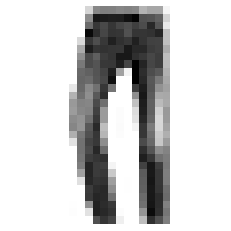

In [32]:
some_item = X_train.values[0]
some_item_image = some_item.reshape(28,28)

plt.imshow(some_item_image, cmap='binary')
plt.axis('off')
plt.show()

Feature creation and standarization



In [33]:
X_train, X_valid, X_test = X_train / 255.0, X_valid / 255.0, X_test / 255.0

In [35]:
class_names = [ "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

#Example:
class_names[y_train[0]]

'Pullover'

In [36]:
X_train.shape

(42000, 784)

Simple Sequential NN model

Epoch 1/25
2625/2625 - 10s - loss: 0.6075 - accuracy: 0.7851 - val_loss: 0.5792 - val_accuracy: 0.8080
Epoch 2/25
2625/2625 - 9s - loss: 0.4883 - accuracy: 0.8257 - val_loss: 0.4843 - val_accuracy: 0.8441
Epoch 3/25
2625/2625 - 9s - loss: 0.4521 - accuracy: 0.8387 - val_loss: 0.4905 - val_accuracy: 0.8527
Epoch 4/25
2625/2625 - 9s - loss: 0.4294 - accuracy: 0.8451 - val_loss: 0.5438 - val_accuracy: 0.8436
Epoch 5/25
2625/2625 - 9s - loss: 0.4215 - accuracy: 0.8492 - val_loss: 0.5634 - val_accuracy: 0.8523
Epoch 6/25
2625/2625 - 9s - loss: 0.4092 - accuracy: 0.8505 - val_loss: 0.8350 - val_accuracy: 0.8668
Epoch 7/25
2625/2625 - 8s - loss: 0.3950 - accuracy: 0.8580 - val_loss: 0.7518 - val_accuracy: 0.8712


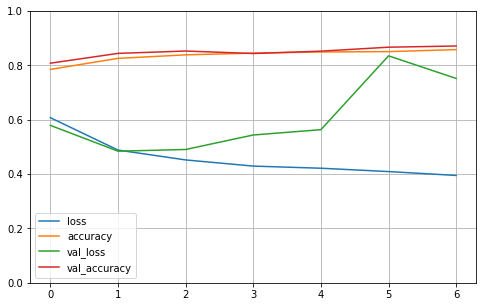

In [52]:
class MyCallBack(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') > 0.99):
            print("\nReached 99% accuracy so cancelling training!")
            self.model.stop_training = True

callback = MyCallBack()

input_dim = X_train.shape[1]
nb_classes = len(y_train.unique())

model = keras.models.Sequential([
                                 keras.layers.Dense(300, activation='relu',input_dim=input_dim),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),
                                 keras.layers.Dense(100, activation='relu'),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),
                                 keras.layers.Dense(nb_classes, activation='softmax'),
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=5, # how many epochs to wait before stopping
    restore_best_weights=True,
)

history = model.fit(X_train,y_train,
          epochs=25,validation_data=(X_valid,y_valid),
          batch_size=16,
          callbacks=[early_stopping],
          verbose=2)

pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [38]:
from sklearn.metrics import accuracy_score
preds = np.argmax(model.predict(X_test), axis=-1)

print('Accuracy in Test: {}'.format(accuracy_score(y_test, preds)))

Accuracy in Test: 0.8813


## Convolutional NN

In [39]:
X_train = X_train.values.reshape(X_train.shape[0], 28, 28, 1)
X_valid = X_valid.values.reshape(X_valid.shape[0], 28, 28, 1)
X_test = X_test.values.reshape(X_test.shape[0], 28, 28, 1)

In [40]:
X_valid.shape

(18000, 28, 28, 1)

In [41]:
from keras.preprocessing.image import ImageDataGenerator

batch_size=32
# Data Augmentation doesn't help improve
# gen = ImageDataGenerator(rotation_range=8, width_shift_range=0.08, shear_range=0.3,
#                                height_shift_range=0.08, zoom_range=0.08, fill_mode='nearest',
#                          horizontal_flip=True)

gen = ImageDataGenerator()

batches = gen.flow(X_train, y_train, batch_size=batch_size)
val_batches = gen.flow(X_valid, y_valid, batch_size=batch_size)

steps_train = int(X_train.shape[0]/batch_size)
steps_valid = int(X_valid.shape[0]/batch_size)

Epoch 1/25
1312/1312 - 40s - loss: 0.7012 - accuracy: 0.7480 - val_loss: 0.4564 - val_accuracy: 0.8331
Epoch 2/25
1312/1312 - 12s - loss: 0.5133 - accuracy: 0.8140 - val_loss: 0.3911 - val_accuracy: 0.8571
Epoch 3/25
1312/1312 - 12s - loss: 0.4550 - accuracy: 0.8347 - val_loss: 0.3843 - val_accuracy: 0.8570
Epoch 4/25
1312/1312 - 12s - loss: 0.4256 - accuracy: 0.8453 - val_loss: 0.3742 - val_accuracy: 0.8613
Epoch 5/25
1312/1312 - 12s - loss: 0.4038 - accuracy: 0.8532 - val_loss: 0.3630 - val_accuracy: 0.8577
Epoch 6/25
1312/1312 - 12s - loss: 0.3877 - accuracy: 0.8600 - val_loss: 0.3494 - val_accuracy: 0.8669
Epoch 7/25
1312/1312 - 12s - loss: 0.3749 - accuracy: 0.8620 - val_loss: 0.3351 - val_accuracy: 0.8703
Epoch 8/25
1312/1312 - 12s - loss: 0.3685 - accuracy: 0.8638 - val_loss: 0.3632 - val_accuracy: 0.8587
Epoch 9/25
1312/1312 - 12s - loss: 0.3563 - accuracy: 0.8700 - val_loss: 0.3260 - val_accuracy: 0.8803
Epoch 10/25
1312/1312 - 12s - loss: 0.3497 - accuracy: 0.8702 - val_loss:

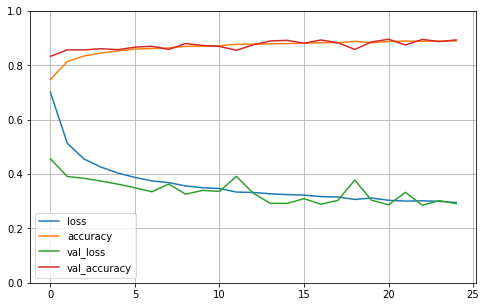

In [42]:
class MyCallBack(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') > 0.99):
            print("\nReached 99% accuracy so cancelling training!")
            self.model.stop_training = True

callback = MyCallBack()

input_dim = X_train.shape[1:]
nb_classes = len(y_train.unique())

model = keras.models.Sequential([
                                 keras.layers.Conv2D(16,(3,3),activation='relu', input_shape=input_dim),
                                 keras.layers.MaxPooling2D(2),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),
                                 keras.layers.Conv2D(32,(3,3),activation='relu'),
                                 keras.layers.MaxPooling2D(2),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),
                                 keras.layers.Conv2D(64,(3,3),activation='relu'),
                                 keras.layers.MaxPooling2D(2),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),
                                 keras.layers.Flatten(),
                                 keras.layers.Dense(300, activation='relu'),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),                                 
                                 keras.layers.Dense(100, activation='relu'),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),
                                 keras.layers.Dense(nb_classes, activation='softmax')])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=5, # how many epochs to wait before stopping
    restore_best_weights=True,
)

history = model.fit(batches, steps_per_epoch=steps_train,
          epochs=25,validation_data=val_batches,
          validation_steps=steps_valid,
          callbacks=[early_stopping],
          verbose=2)

pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [45]:
from sklearn.metrics import accuracy_score
preds = np.argmax(model.predict(X_test), axis=-1)

print('Accuracy in Test: {}'.format(accuracy_score(y_test, preds)))

Accuracy in Test: 0.9003


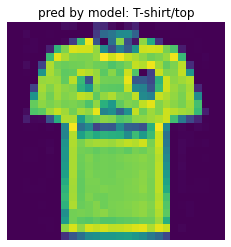

In [47]:
## Example pred

mini_pred = np.argmax(model.predict(X_test[0].reshape(1,28,28,1)),axis=-1)

plt.imshow(X_test[0].reshape(28,28))
plt.title(f'pred by model: {class_names[mini_pred[0]]}')
plt.axis('off')
plt.show()